Library import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Obtaining data

Data input and short brief about that data from Kaggle:

This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

Content
The datasets consists of several medical predictor variables and one target variable, Outcome. Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

In [2]:
df = pd.read_csv('data/diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Scrubing Data

In [6]:
cols_with_zeros = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

In [7]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


For the purpose of bulding machine learning model i need to replace NaN with data

In [8]:
# Fill missing values with median of each column
df[cols_with_zeros] = df[cols_with_zeros].fillna(df[cols_with_zeros].median())

# Verify no missing values left
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Exploring a data

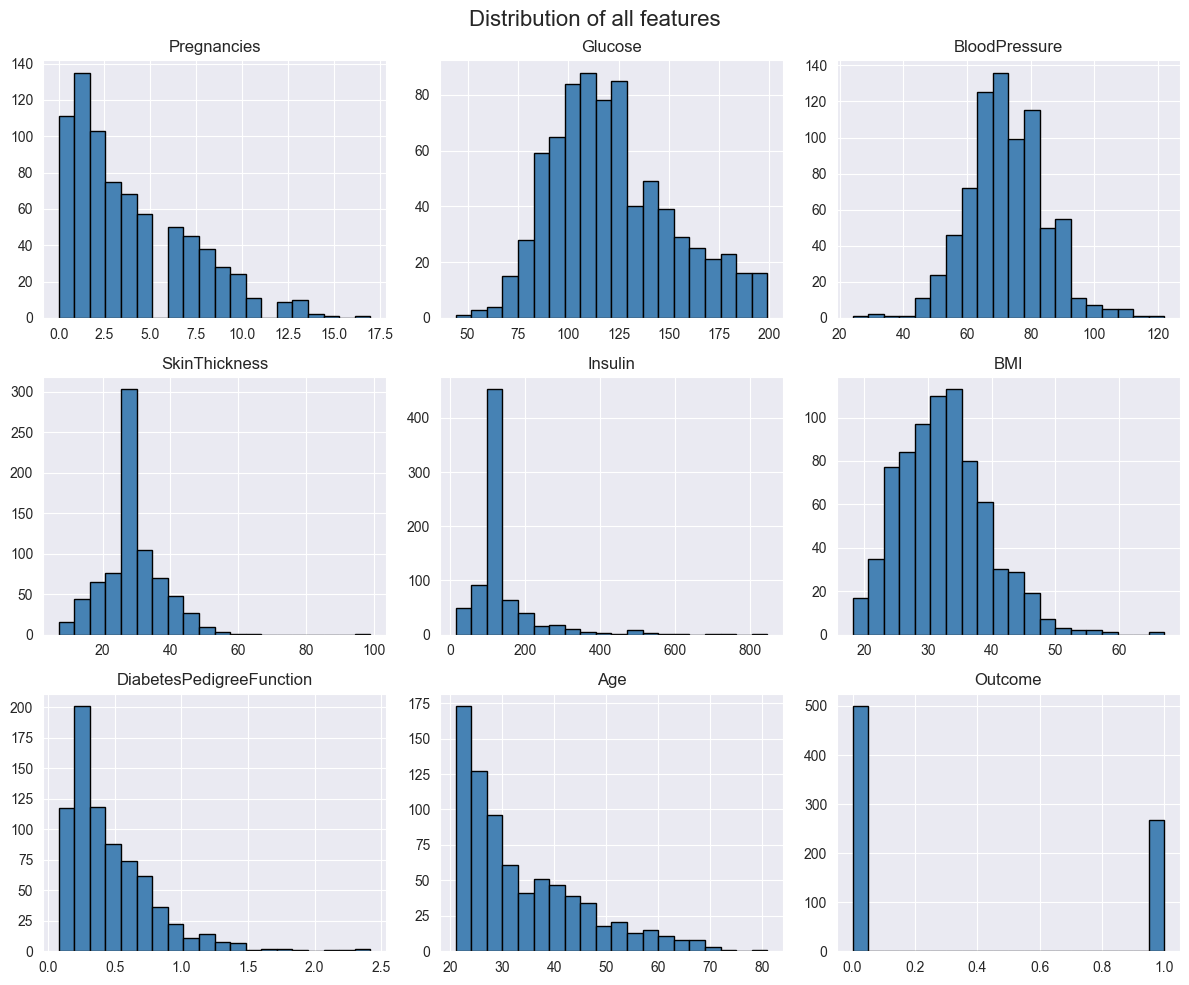

In [9]:
df.hist(figsize=(12, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of all features', fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
print(df['Outcome'].value_counts())
print("\nPercentage:")
print(df['Outcome'].value_counts(normalize=True) * 100)

Outcome
0    500
1    268
Name: count, dtype: int64

Percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


## EDA Observations
- Dataset has 768 patients
- Class imbalance: 65% healthy (0) vs 35% diabetic (1)
- This means accuracy alone is not a good metric — we need to check Precision, Recall and ROC-AUC